# FD003 - Internal Validation Evaluation Report

**Advertencia metodologica:** este notebook usa solo validacion interna construida desde `train_FD003.txt`. No se usa `test_FD003.txt`, no se usa `RUL_FD003.txt` y no se reporta evaluacion oficial de test.

Objetivo: resumir y visualizar el desempeno del modelo final interno de FD003 para informe/poster.

## 1. Setup

Se cargan librerias, se detecta la raiz del proyecto y se crean las carpetas de salida. Todas las tablas y figuras se guardan en las carpetas FD003 correspondientes.

In [1]:
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "CMAPSSData").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.fd003_improvement_utils import (
    FD003_RANDOM_STATES,
    add_rul_bins_to_predictions,
    ensure_fd003_dirs,
    evaluate_fd003_config_split,
    load_json,
    save_json,
)

PATHS = ensure_fd003_dirs(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "CMAPSSData"
RESULTS_DIR = PATHS["results"]
FIGURES_DIR = PATHS["figures"]
CONFIGS_DIR = PATHS["configs"]
NOTES_DIR = PATHS["notes"]

read_files = []
generated_files = []

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Resultados: {RESULTS_DIR}")
print(f"Figuras: {FIGURES_DIR}")

Proyecto: C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML
Resultados: C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\results\FD003
Figuras: C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\figures\FD003


## 2. Configuracion final del modelo

Se carga la configuracion cerrada de FD003 y se verifica que corresponda al candidato final interno. El refinamiento de hiperparametros queda solo como comparacion descartada.

In [2]:
final_config_path = CONFIGS_DIR / "fd003_final_candidate_config.json"
if not final_config_path.exists():
    raise FileNotFoundError(f"No existe la config final esperada: {final_config_path}")

final_config = load_json(final_config_path)
read_files.append(str(final_config_path.relative_to(PROJECT_ROOT)))

expected = {
    "model_name": "fd003_lgbm_w50_cap125_quantile_a04_none_fault_sensitive",
    "feature_set": "fault_sensitive",
    "window_size": 50,
    "rul_cap": 125,
    "objective": "quantile",
    "alpha": 0.4,
    "sample_weight_scheme": "none",
    "official_test_used_for_selection": False,
}

warnings_found = []
for key, expected_value in expected.items():
    actual = final_config.get(key)
    if actual != expected_value:
        warnings_found.append(f"{key}: esperado {expected_value}, encontrado {actual}")

config_rows = []
for key in [
    "model_name", "model_family", "feature_set", "window_size", "rul_cap", "objective", "alpha",
    "sample_weight_scheme", "selected_by", "validation_protocol", "official_test_used",
    "official_test_used_for_selection",
]:
    config_rows.append({"field": key, "value": final_config.get(key)})
for key, value in final_config.get("hyperparameters", {}).items():
    config_rows.append({"field": f"hyperparameters.{key}", "value": value})

config_table = pd.DataFrame(config_rows)
config_table_path = RESULTS_DIR / "fd003_internal_validation_final_model_config_table.csv"
config_table.to_csv(config_table_path, index=False)
generated_files.append(str(config_table_path.relative_to(PROJECT_ROOT)))

display(config_table)
if warnings_found:
    display(Markdown("**Advertencias de configuracion:**\n" + "\n".join(f"- {w}" for w in warnings_found)))
else:
    display(Markdown("**Configuracion verificada:** coincide con el modelo final interno esperado."))

,field,value
0,model_name,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...
1,model_family,LightGBM
2,feature_set,fault_sensitive
3,window_size,50
4,rul_cap,125
5,objective,quantile
6,alpha,0.4
7,sample_weight_scheme,none
8,selected_by,artificial_validation_multi_split
9,validation_protocol,"train_FD003 only, held-out units, artificial c..."


**Configuracion verificada:** coincide con el modelo final interno esperado.

## 3. Predicciones internas del modelo final

Primero se intenta usar predicciones internas ya generadas. Si no existen, se recalcula la validacion interna usando solo `train_FD003.txt`, sin tuning y sin modificar el modelo.

In [3]:
standard_predictions_path = RESULTS_DIR / "fd003_internal_validation_final_model_predictions.csv"
pseudo_predictions_path = RESULTS_DIR / "fd003_pseudo_cluster_validation_predictions.csv"
required_prediction_cols = {
    "unit_number", "cutoff_cycle", "true_rul", "pred_rul", "error", "abs_error",
    "squared_error", "dangerous_error", "conservative_error", "cmapss_penalty",
}

source_predictions = None
prediction_source = None

if standard_predictions_path.exists():
    source_predictions = pd.read_csv(standard_predictions_path)
    prediction_source = standard_predictions_path
elif pseudo_predictions_path.exists():
    pseudo_predictions = pd.read_csv(pseudo_predictions_path)
    if "variant" in pseudo_predictions.columns:
        source_predictions = pseudo_predictions.loc[pseudo_predictions["variant"] == "global_baseline"].copy()
        prediction_source = pseudo_predictions_path

if source_predictions is not None and not required_prediction_cols.issubset(source_predictions.columns):
    source_predictions = None
    prediction_source = None

if source_predictions is None:
    display(Markdown("**Warning:** no se encontraron predicciones internas usables. Se recalcula validacion interna desde `train_FD003.txt`."))
    prediction_tables = []
    for state in FD003_RANDOM_STATES:
        _, preds, _ = evaluate_fd003_config_split(
            config=final_config,
            data_dir=DATA_DIR,
            random_state=state,
        )
        prediction_tables.append(preds)
    predictions = pd.concat(prediction_tables, ignore_index=True)
    prediction_source = "recalculated_from_train_FD003"
else:
    predictions = source_predictions.copy()
    read_files.append(str(prediction_source.relative_to(PROJECT_ROOT)))

if "random_state" in predictions.columns and "split_seed" not in predictions.columns:
    predictions = predictions.rename(columns={"random_state": "split_seed"})
if "split_seed" not in predictions.columns:
    predictions["split_seed"] = np.nan

predictions = predictions[[
    "split_seed", "unit_number", "cutoff_cycle", "true_rul", "pred_rul", "error", "abs_error",
    "squared_error", "dangerous_error", "conservative_error", "cmapss_penalty"
]].copy()
predictions["rul_bin"] = pd.cut(
    predictions["true_rul"],
    bins=[0, 31, 61, 101, np.inf],
    labels=["0-30", "31-60", "61-100", "101+"],
    right=False,
    include_lowest=True,
)

predictions.to_csv(standard_predictions_path, index=False)
generated_files.append(str(standard_predictions_path.relative_to(PROJECT_ROOT)))

print("Fuente de predicciones:", prediction_source)
print("Shape:", predictions.shape)
display(predictions.head())

Fuente de predicciones: C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\results\FD003\fd003_pseudo_cluster_validation_predictions.csv
Shape: (500, 12)


,split_seed,unit_number,cutoff_cycle,true_rul,pred_rul,error,abs_error,squared_error,dangerous_error,conservative_error,cmapss_penalty,rul_bin
0,0,3,82,140.0,121.239458,-18.760542,18.760542,351.957945,False,False,3.233879,101+
1,0,3,112,110.0,111.517556,1.517556,1.517556,2.302976,False,False,0.163876,101+
2,0,3,142,80.0,96.993704,16.993704,16.993704,288.785974,False,False,4.470502,61-100
3,0,3,172,50.0,51.617979,1.617979,1.617979,2.617857,False,False,0.175623,31-60
4,0,3,202,20.0,20.909037,0.909037,0.909037,0.826349,False,False,0.095164,0-30


## 4. Metricas globales de validacion interna

Se calculan metricas sobre todas las predicciones internas y tambien C-MAPSS agregado por split para mantener consistencia con las comparaciones anteriores.

In [4]:
def compute_prediction_metrics(df):
    y_true = df["true_rul"].to_numpy(dtype=float)
    y_pred = df["pred_rul"].to_numpy(dtype=float)
    return {
        "n_predictions": int(len(df)),
        "n_units": int(df["unit_number"].nunique()),
        "n_splits": int(df["split_seed"].nunique()),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)) if len(np.unique(y_true)) > 1 else np.nan,
        "cmapss_total_all_predictions": float(df["cmapss_penalty"].sum()),
        "cmapss_mean_penalty": float(df["cmapss_penalty"].mean()),
        "dangerous_error_pct": float(df["dangerous_error"].mean() * 100.0),
        "conservative_error_pct": float(df["conservative_error"].mean() * 100.0),
        "bias_mean": float(df["error"].mean()),
        "median_error": float(df["error"].median()),
        "abs_error_p90": float(df["abs_error"].quantile(0.90)),
        "abs_error_p95": float(df["abs_error"].quantile(0.95)),
        "max_abs_error": float(df["abs_error"].max()),
    }

metrics = compute_prediction_metrics(predictions)
split_metrics = []
for split_seed, group in predictions.groupby("split_seed"):
    row = compute_prediction_metrics(group)
    row["split_seed"] = split_seed
    row["cmapss_score"] = float(group["cmapss_penalty"].sum())
    split_metrics.append(row)
split_metrics = pd.DataFrame(split_metrics)
metrics["mean_cmapss_score_by_split"] = float(split_metrics["cmapss_score"].mean())
metrics["std_cmapss_score_by_split"] = float(split_metrics["cmapss_score"].std(ddof=1))
metrics["worst_cmapss_score_by_split"] = float(split_metrics["cmapss_score"].max())
metrics["worst_rmse_by_split"] = float(split_metrics["rmse"].max())
metrics["worst_dangerous_error_pct_by_split"] = float(split_metrics["dangerous_error_pct"].max())

metrics_table = pd.DataFrame([metrics])
metrics_path = RESULTS_DIR / "fd003_internal_validation_final_metrics.csv"
metrics_table.to_csv(metrics_path, index=False)
generated_files.append(str(metrics_path.relative_to(PROJECT_ROOT)))

display(metrics_table.T.rename(columns={0: "value"}))

,value
n_predictions,500.000000
n_units,71.000000
n_splits,5.000000
mae,12.162365
rmse,16.397563
r2,0.850622
cmapss_total_all_predictions,2020.911692
cmapss_mean_penalty,4.041823
dangerous_error_pct,5.000000
conservative_error_pct,13.600000


## 5. Metricas por rango de RUL

Los bins permiten ver donde el modelo se comporta mejor o peor: cerca de la falla, en RUL medio y en RUL alto.

In [5]:
bin_rows = []
for rul_bin, group in predictions.groupby("rul_bin", observed=True):
    row = compute_prediction_metrics(group)
    row["rul_bin"] = str(rul_bin)
    bin_rows.append(row)
metrics_by_bin = pd.DataFrame(bin_rows)[[
    "rul_bin", "n_predictions", "n_units", "mae", "rmse", "cmapss_total_all_predictions",
    "cmapss_mean_penalty", "dangerous_error_pct", "conservative_error_pct", "bias_mean",
    "abs_error_p90", "abs_error_p95",
]]
metrics_by_bin_path = RESULTS_DIR / "fd003_internal_validation_final_metrics_by_rul_bin.csv"
metrics_by_bin.to_csv(metrics_by_bin_path, index=False)
generated_files.append(str(metrics_by_bin_path.relative_to(PROJECT_ROOT)))

display(metrics_by_bin)

,rul_bin,n_predictions,n_units,mae,rmse,cmapss_total_all_predictions,cmapss_mean_penalty,dangerous_error_pct,conservative_error_pct,bias_mean,abs_error_p90,abs_error_p95
0,0-30,100,71,3.253793,4.264005,39.211245,0.392112,0.0,0.0,0.253894,6.537364,8.951729
1,31-60,100,71,8.094769,11.183978,274.993327,2.749933,6.0,0.0,3.103672,18.532236,21.998122
2,61-100,100,71,13.682578,16.685525,542.043284,5.420433,19.0,3.0,6.083655,27.997957,32.609809
3,101+,200,71,17.890341,21.479414,1164.663835,5.823319,0.0,32.5,-13.848360,36.137951,41.127265


## 6. Comparacion con experimentos anteriores

Se arma una tabla limpia con las etapas principales: transferencia, tuning, features sensibles, pseudo-clusters, refinamiento y candidato final seleccionado.

In [6]:
read_candidates = [
    RESULTS_DIR / "fd003_model_improvement_global_comparison_refined.csv",
    RESULTS_DIR / "fd003_model_improvement_global_comparison.csv",
    RESULTS_DIR / "fd003_short_tuning_summary.csv",
    RESULTS_DIR / "fd003_fault_sensitive_features_summary.csv",
    RESULTS_DIR / "fd003_pseudo_cluster_experiments_summary.csv",
    RESULTS_DIR / "fd003_lgbm_hyperparam_refinement_comparison_vs_current.csv",
    RESULTS_DIR / "fd003_transfer_fd001_pipeline_validation_summary.csv",
]
for path in read_candidates:
    if path.exists():
        read_files.append(str(path.relative_to(PROJECT_ROOT)))

global_refined_path = RESULTS_DIR / "fd003_model_improvement_global_comparison_refined.csv"
if global_refined_path.exists():
    comparison_report = pd.read_csv(global_refined_path).copy()
    comparison_report = comparison_report.rename(columns={
        "model_name": "modelo",
        "mean_MAE": "MAE",
        "mean_RMSE": "RMSE",
        "mean_R2": "R2",
        "mean_CMAPSS": "C_MAPSS",
        "std_CMAPSS": "std_C_MAPSS",
        "mean_bias": "bias",
    })
else:
    raise FileNotFoundError("Falta fd003_model_improvement_global_comparison_refined.csv para armar la comparacion limpia.")

decision_map = {
    "FD001 transfer baseline sobre FD003": ("descartado", "Baseline fuerte, pero superado por features fault-sensitive."),
    "FD003 short tuning best": ("descartado", "No supero al pipeline transferido."),
    "FD003 fault-sensitive features best": ("aceptado", "Mejor mejora defendible antes del refinamiento."),
    "FD003 pseudo-cluster best": ("descartado", "Pseudo-clusters no mejoraron frente al baseline fault-sensitive."),
    "FD003 current final candidate": ("aceptado", "Candidato final actual usado para el reporte interno."),
    "FD003 hyperparam refinement best": ("descartado", "Mejora C-MAPSS marginal, pero sube dangerous error."),
    "FD003 final selected candidate": ("final", "Se mantiene el candidato fault-sensitive actual."),
}
comparison_report["decision"] = comparison_report["approach"].map(lambda x: decision_map.get(x, ("", ""))[0])
comparison_report["motivo"] = comparison_report["approach"].map(lambda x: decision_map.get(x, ("", ""))[1])
comparison_report = comparison_report[[
    "modelo", "approach", "MAE", "RMSE", "R2", "C_MAPSS", "std_C_MAPSS",
    "mean_dangerous_error_pct", "mean_conservative_error_pct", "bias", "worst_CMAPSS",
    "decision", "motivo",
]]

comparison_report_path = RESULTS_DIR / "fd003_internal_validation_model_comparison_report.csv"
comparison_report.to_csv(comparison_report_path, index=False)
generated_files.append(str(comparison_report_path.relative_to(PROJECT_ROOT)))

display(comparison_report)

,modelo,approach,MAE,RMSE,R2,C_MAPSS,std_C_MAPSS,mean_dangerous_error_pct,mean_conservative_error_pct,bias,worst_CMAPSS,decision,motivo
0,candidate_03_B_quantile_a040_search_14,FD001 transfer baseline sobre FD003,12.079831,16.448624,0.848610,424.430214,84.284135,5.6,13.4,-3.593095,555.049531,descartado,"Baseline fuerte, pero superado por features fa..."
1,fd003_lgbm_w50_cap125_quantile_a04_none,FD003 short tuning best,12.079831,16.448624,0.848610,424.430214,84.284135,5.6,13.4,-3.593095,555.049531,descartado,No supero al pipeline transferido.
2,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,FD003 fault-sensitive features best,12.162365,16.367037,0.850622,404.182338,38.602982,5.0,13.6,-3.651100,443.161862,aceptado,Mejor mejora defendible antes del refinamiento.
3,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,FD003 pseudo-cluster best,12.162365,16.367037,0.850622,404.182338,38.602982,5.0,13.6,-3.651100,443.161862,descartado,Pseudo-clusters no mejoraron frente al baselin...
4,fd003_lgbm_refinement_baseline_current,FD003 current final candidate,12.162365,16.367037,0.850622,404.182338,38.602982,5.0,13.6,-3.651100,443.161862,aceptado,Candidato final actual usado para el reporte i...
5,fd003_lgbm_refinement_search_20,FD003 hyperparam refinement best,12.160812,16.259892,0.852455,400.787131,44.369108,5.4,13.4,-3.126702,439.738981,descartado,"Mejora C-MAPSS marginal, pero sube dangerous e..."
6,fd003_lgbm_refinement_baseline_current,FD003 final selected candidate,12.162365,16.367037,0.850622,404.182338,38.602982,5.0,13.6,-3.651100,443.161862,final,Se mantiene el candidato fault-sensitive actual.


## 7. Visualizaciones del modelo final

Las figuras se muestran inline y tambien se guardan en `figures/FD003/`.

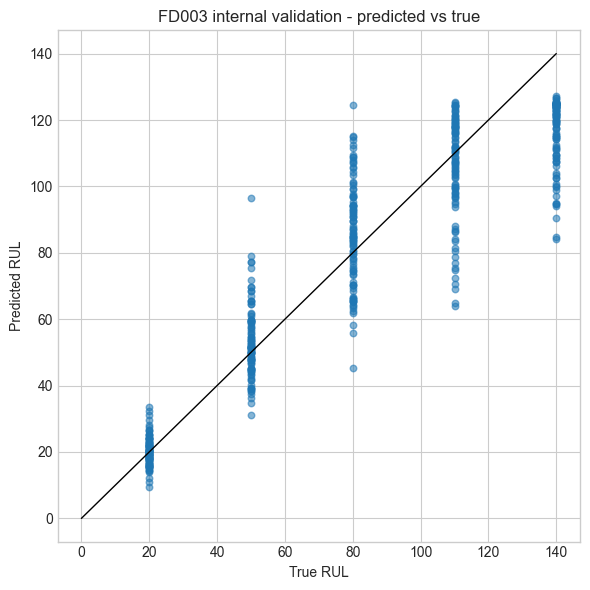

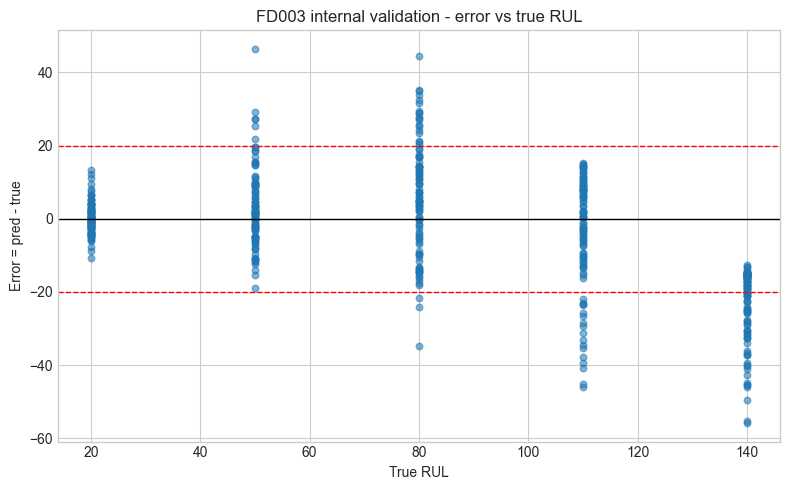

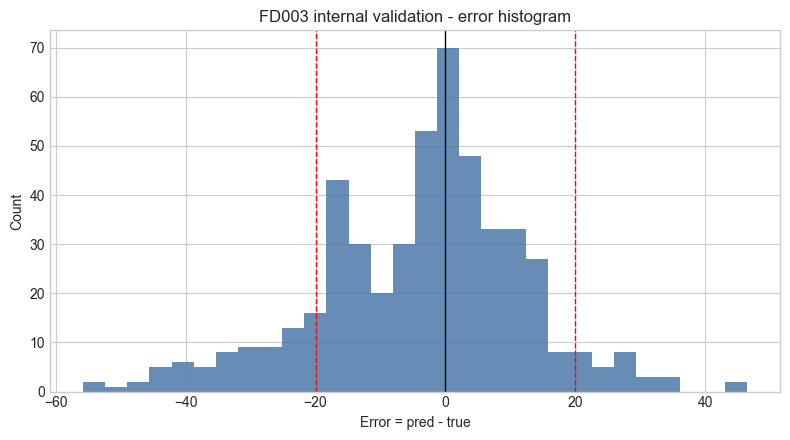

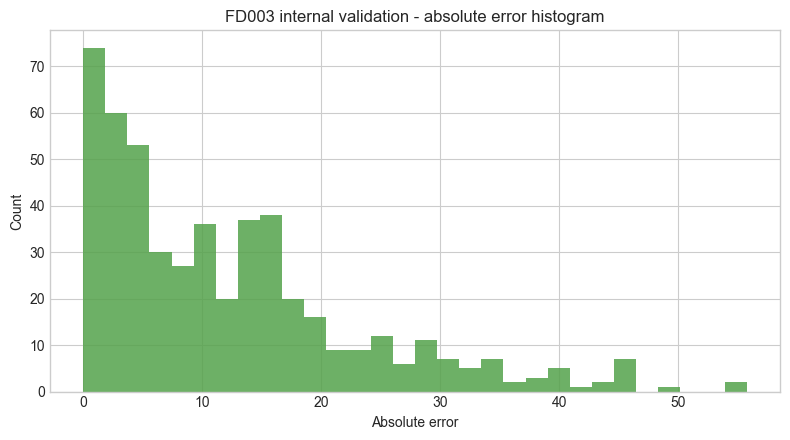

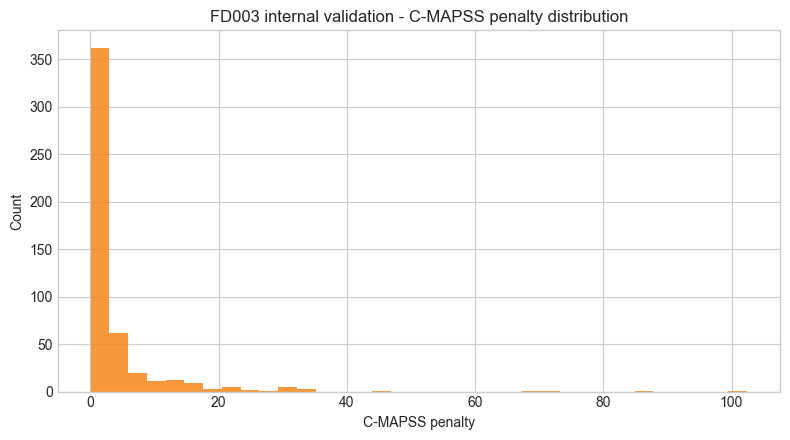

In [7]:
# A. Predicho vs real
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(predictions["true_rul"], predictions["pred_rul"], s=22, alpha=0.55)
max_axis = max(predictions["true_rul"].max(), predictions["pred_rul"].max())
ax.plot([0, max_axis], [0, max_axis], color="black", linewidth=1)
ax.set_xlabel("True RUL")
ax.set_ylabel("Predicted RUL")
ax.set_title("FD003 internal validation - predicted vs true")
fig.tight_layout()
path = FIGURES_DIR / "fd003_internal_validation_pred_vs_true.png"
fig.savefig(path, dpi=160)
generated_files.append(str(path.relative_to(PROJECT_ROOT)))
plt.show()

# B. Error vs true RUL
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(predictions["true_rul"], predictions["error"], s=22, alpha=0.55)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(20, color="red", linestyle="--", linewidth=1)
ax.axhline(-20, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("True RUL")
ax.set_ylabel("Error = pred - true")
ax.set_title("FD003 internal validation - error vs true RUL")
fig.tight_layout()
path = FIGURES_DIR / "fd003_internal_validation_error_vs_true_rul.png"
fig.savefig(path, dpi=160)
generated_files.append(str(path.relative_to(PROJECT_ROOT)))
plt.show()

# C. Histograma de errores
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(predictions["error"], bins=30, color="#4c78a8", alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(20, color="red", linestyle="--", linewidth=1)
ax.axvline(-20, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Error = pred - true")
ax.set_ylabel("Count")
ax.set_title("FD003 internal validation - error histogram")
fig.tight_layout()
path = FIGURES_DIR / "fd003_internal_validation_error_histogram.png"
fig.savefig(path, dpi=160)
generated_files.append(str(path.relative_to(PROJECT_ROOT)))
plt.show()

# D. Histograma de errores absolutos
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(predictions["abs_error"], bins=30, color="#54a24b", alpha=0.85)
ax.set_xlabel("Absolute error")
ax.set_ylabel("Count")
ax.set_title("FD003 internal validation - absolute error histogram")
fig.tight_layout()
path = FIGURES_DIR / "fd003_internal_validation_abs_error_histogram.png"
fig.savefig(path, dpi=160)
generated_files.append(str(path.relative_to(PROJECT_ROOT)))
plt.show()

# E. C-MAPSS penalty distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(predictions["cmapss_penalty"], bins=35, color="#f58518", alpha=0.85)
ax.set_xlabel("C-MAPSS penalty")
ax.set_ylabel("Count")
ax.set_title("FD003 internal validation - C-MAPSS penalty distribution")
fig.tight_layout()
path = FIGURES_DIR / "fd003_internal_validation_cmapss_penalty_distribution.png"
fig.savefig(path, dpi=160)
generated_files.append(str(path.relative_to(PROJECT_ROOT)))
plt.show()

## 8. Peores casos y ranking de mantenimiento interno

Los peores casos se ordenan por penalizacion C-MAPSS. El ranking de mantenimiento prioriza los casos con menor RUL predicho dentro de la validacion interna.

,split_seed,unit_number,cutoff_cycle,true_rul,pred_rul,error,cmapss_penalty
1258,4,42,143,50.0,96.389820,46.389820,102.438994
357,1,66,85,80.0,124.564264,44.564264,85.178992
620,2,15,62,140.0,84.223642,-55.776358,72.002163
610,2,4,132,140.0,84.664320,-55.335680,69.568987
10,0,9,266,140.0,90.372642,-49.627358,44.489845
90,0,94,252,140.0,94.031777,-45.968223,33.329915
11,0,9,296,110.0,64.077894,-45.922106,33.208346
1257,4,42,113,80.0,115.109971,35.109971,32.481637
937,3,46,124,80.0,114.975921,34.975921,32.035808
5,0,8,127,140.0,94.640997,-45.359003,31.758226


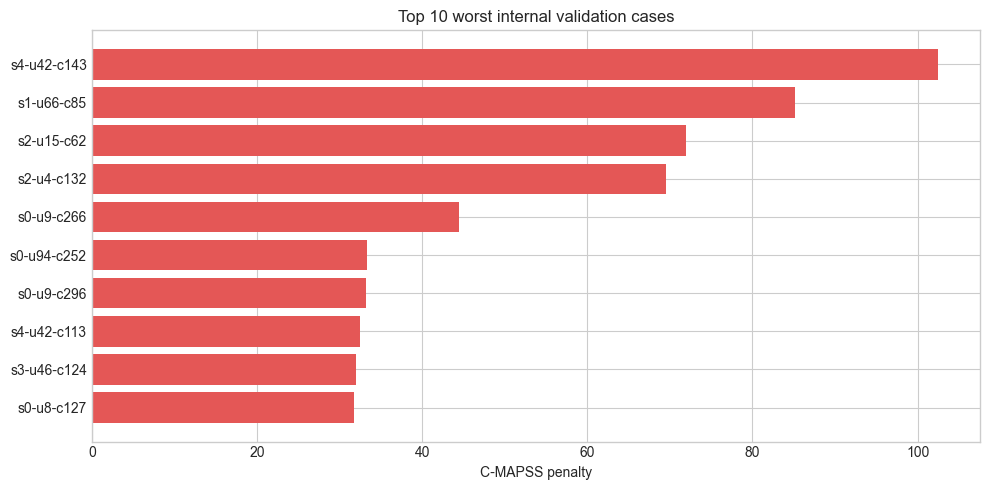

,split_seed,unit_number,cutoff_cycle,true_rul,pred_rul,error
924,3,26,223,20.0,9.311194,-10.688806
1249,4,36,304,20.0,11.076463,-8.923537
49,0,34,439,20.0,12.244271,-7.755729
39,0,27,300,20.0,13.963551,-6.036449
384,1,83,161,20.0,14.296988,-5.703012
624,2,15,182,20.0,14.563845,-5.436155
609,2,3,202,20.0,14.681619,-5.318381
324,1,34,439,20.0,15.041626,-4.958374
969,3,78,201,20.0,15.416988,-4.583012
1279,4,55,505,20.0,15.490419,-4.509581


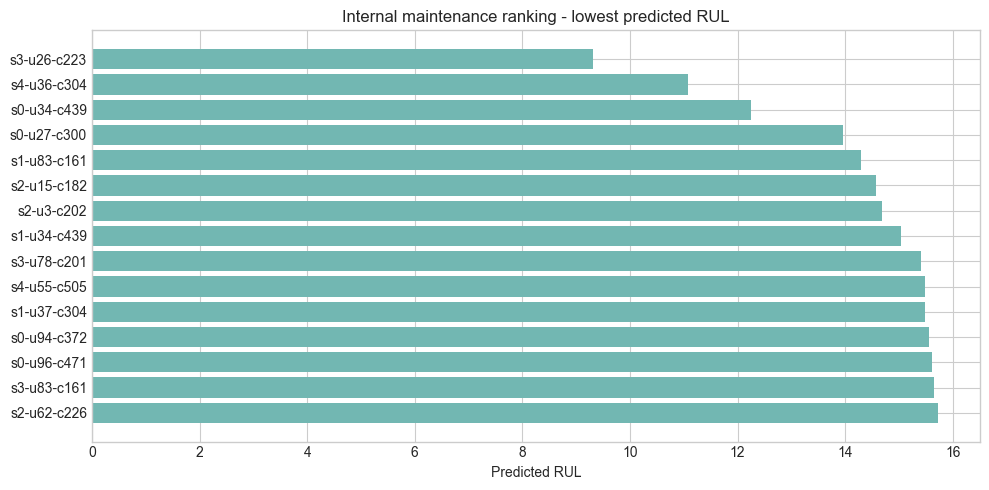

In [8]:
top10_worst = predictions.sort_values("cmapss_penalty", ascending=False).head(10)[[
    "split_seed", "unit_number", "cutoff_cycle", "true_rul", "pred_rul", "error", "cmapss_penalty"
]].copy()
display(top10_worst)

fig, ax = plt.subplots(figsize=(10, 5))
labels = top10_worst.apply(lambda r: f"s{int(r['split_seed'])}-u{int(r['unit_number'])}-c{int(r['cutoff_cycle'])}", axis=1)
ax.barh(labels, top10_worst["cmapss_penalty"], color="#e45756")
ax.invert_yaxis()
ax.set_xlabel("C-MAPSS penalty")
ax.set_title("Top 10 worst internal validation cases")
fig.tight_layout()
path = FIGURES_DIR / "fd003_internal_validation_top10_worst_cases.png"
fig.savefig(path, dpi=160)
generated_files.append(str(path.relative_to(PROJECT_ROOT)))
plt.show()

maintenance_ranking = predictions.sort_values("pred_rul", ascending=True).head(15)[[
    "split_seed", "unit_number", "cutoff_cycle", "true_rul", "pred_rul", "error"
]].copy()
display(maintenance_ranking)

fig, ax = plt.subplots(figsize=(10, 5))
labels = maintenance_ranking.apply(lambda r: f"s{int(r['split_seed'])}-u{int(r['unit_number'])}-c{int(r['cutoff_cycle'])}", axis=1)
ax.barh(labels, maintenance_ranking["pred_rul"], color="#72b7b2")
ax.invert_yaxis()
ax.set_xlabel("Predicted RUL")
ax.set_title("Internal maintenance ranking - lowest predicted RUL")
fig.tight_layout()
path = FIGURES_DIR / "fd003_internal_validation_maintenance_ranking.png"
fig.savefig(path, dpi=160)
generated_files.append(str(path.relative_to(PROJECT_ROOT)))
plt.show()

## 9. Visualizaciones por bin y comparacion entre modelos

Se muestra como cambian las metricas por rango de RUL y como evolucionaron los experimentos de FD003.

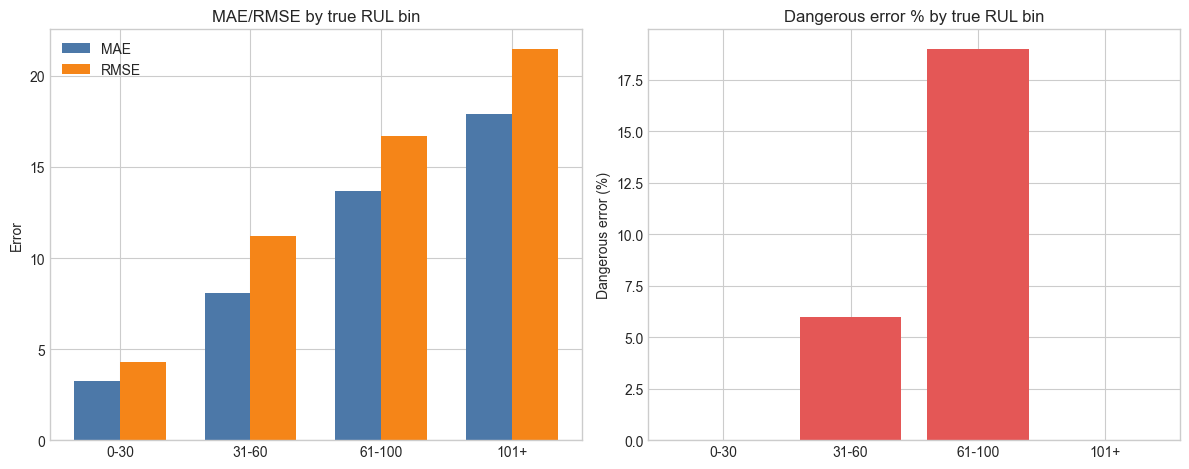

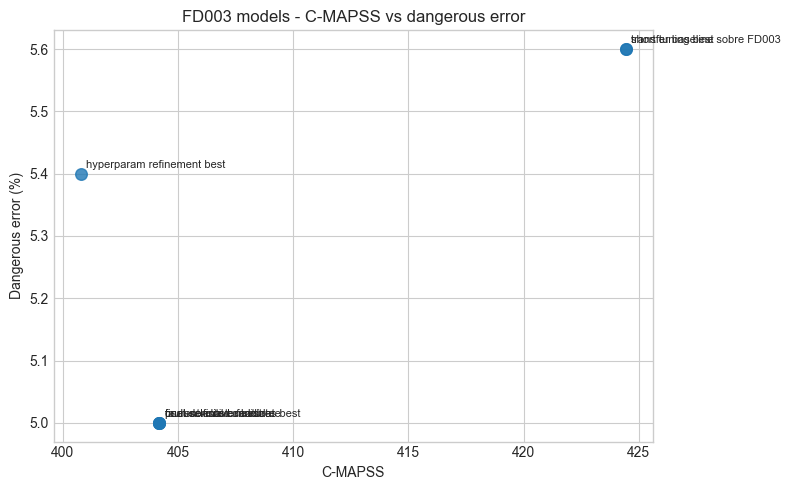

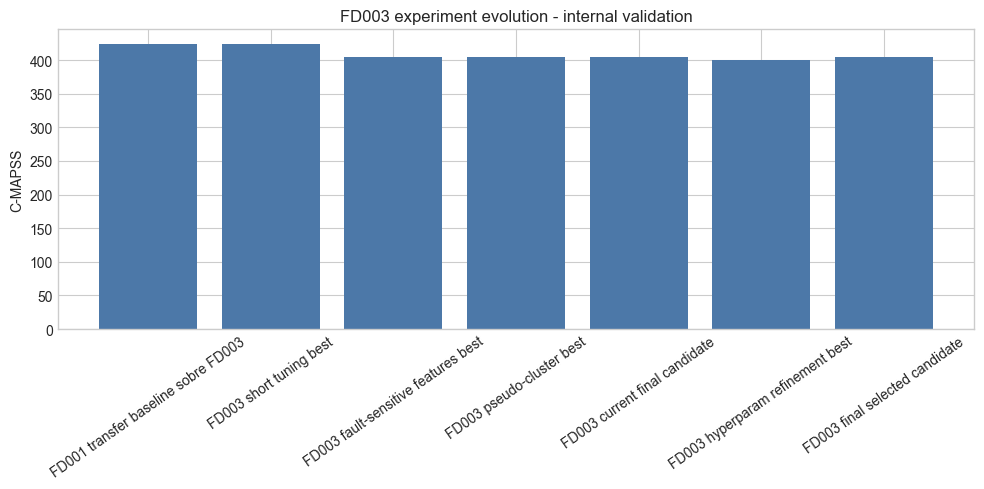

,row_type,config_index,hyperparameter_search_label,model_name,approach,window_size,rul_cap,objective,alpha,sample_weight_scheme,...,std_abs_error_p95,worst_rmse,worst_cmapss_score,worst_dangerous_error_pct,delta_vs_current_mean_cmapss_score,delta_vs_current_worst_cmapss_score,delta_vs_current_mean_dangerous_error_pct,delta_vs_current_mean_rmse,delta_vs_current_mean_mae,delta_vs_current_mean_bias_mean
0,current_candidate,0,baseline_current,fd003_lgbm_refinement_baseline_current,lgbm_hyperparam_refinement,50,125,quantile,0.4,none,...,3.782988,17.896168,443.161862,8.0,NaN,NaN,NaN,NaN,NaN,NaN
1,best_refinement,20,search_20,fd003_lgbm_refinement_search_20,lgbm_hyperparam_refinement,50,125,quantile,0.4,none,...,2.567582,17.928736,439.738981,9.0,-3.395207,-3.422881,0.4,-0.107145,-0.001552,0.524398


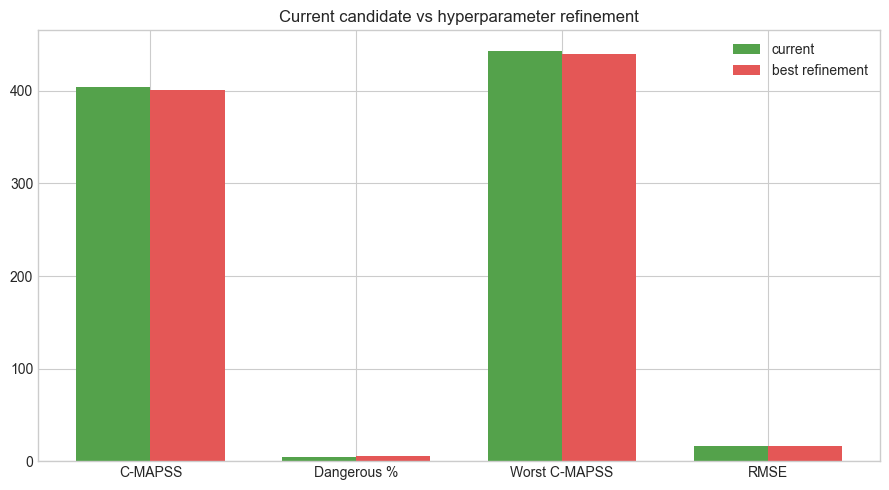

In [9]:
# G. Metricas por RUL bin
bin_order = ["0-30", "31-60", "61-100", "101+"]
plot_bins = metrics_by_bin.copy()
plot_bins["rul_bin"] = pd.Categorical(plot_bins["rul_bin"], categories=bin_order, ordered=True)
plot_bins = plot_bins.sort_values("rul_bin")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
width = 0.35
x = np.arange(len(plot_bins))
axes[0].bar(x - width / 2, plot_bins["mae"], width, label="MAE", color="#4c78a8")
axes[0].bar(x + width / 2, plot_bins["rmse"], width, label="RMSE", color="#f58518")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_bins["rul_bin"])
axes[0].set_title("MAE/RMSE by true RUL bin")
axes[0].set_ylabel("Error")
axes[0].legend()
axes[1].bar(plot_bins["rul_bin"].astype(str), plot_bins["dangerous_error_pct"], color="#e45756")
axes[1].set_title("Dangerous error % by true RUL bin")
axes[1].set_ylabel("Dangerous error (%)")
fig.tight_layout()
path = FIGURES_DIR / "fd003_internal_validation_metrics_by_rul_bin.png"
fig.savefig(path, dpi=160)
generated_files.append(str(path.relative_to(PROJECT_ROOT)))
plt.show()

# H. C-MAPSS vs dangerous error por modelo
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(comparison_report["C_MAPSS"], comparison_report["mean_dangerous_error_pct"], s=70, alpha=0.8)
for _, row in comparison_report.iterrows():
    label = row["approach"].replace("FD003 ", "").replace("FD001 ", "")
    ax.annotate(label, (row["C_MAPSS"], row["mean_dangerous_error_pct"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("C-MAPSS")
ax.set_ylabel("Dangerous error (%)")
ax.set_title("FD003 models - C-MAPSS vs dangerous error")
fig.tight_layout()
path = FIGURES_DIR / "fd003_internal_validation_cmapss_vs_dangerous_models.png"
fig.savefig(path, dpi=160)
generated_files.append(str(path.relative_to(PROJECT_ROOT)))
plt.show()

# I. Evolucion de experimentos
fig, ax = plt.subplots(figsize=(10, 5))
evolution = comparison_report.copy()
ax.bar(evolution["approach"], evolution["C_MAPSS"], color="#4c78a8")
ax.set_ylabel("C-MAPSS")
ax.set_title("FD003 experiment evolution - internal validation")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
path = FIGURES_DIR / "fd003_internal_validation_experiment_evolution.png"
fig.savefig(path, dpi=160)
generated_files.append(str(path.relative_to(PROJECT_ROOT)))
plt.show()

# J. Comparacion candidato actual vs refinamiento
refinement_compare_path = RESULTS_DIR / "fd003_lgbm_hyperparam_refinement_comparison_vs_current.csv"
if refinement_compare_path.exists():
    refinement_compare = pd.read_csv(refinement_compare_path)
    read_files.append(str(refinement_compare_path.relative_to(PROJECT_ROOT)))
    display(refinement_compare)
    current = refinement_compare.loc[refinement_compare["row_type"] == "current_candidate"].iloc[0]
    refined = refinement_compare.loc[refinement_compare["row_type"] == "best_refinement"].iloc[0]
    metric_labels = ["C-MAPSS", "Dangerous %", "Worst C-MAPSS", "RMSE"]
    current_values = [current["mean_cmapss_score"], current["mean_dangerous_error_pct"], current["worst_cmapss_score"], current["mean_rmse"]]
    refined_values = [refined["mean_cmapss_score"], refined["mean_dangerous_error_pct"], refined["worst_cmapss_score"], refined["mean_rmse"]]
    x = np.arange(len(metric_labels))
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - 0.18, current_values, 0.36, label="current", color="#54a24b")
    ax.bar(x + 0.18, refined_values, 0.36, label="best refinement", color="#e45756")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_title("Current candidate vs hyperparameter refinement")
    ax.legend()
    fig.tight_layout()
    path = FIGURES_DIR / "fd003_internal_validation_current_vs_refinement.png"
    fig.savefig(path, dpi=160)
    generated_files.append(str(path.relative_to(PROJECT_ROOT)))
    plt.show()
else:
    display(Markdown("**Warning:** no se encontro comparacion current vs refinement."))

## 10. Interpretacion final

Se guarda y muestra una lectura final del desempeno interno. Esta interpretacion no debe presentarse como evaluacion oficial de test.

In [10]:
best_bin = metrics_by_bin.sort_values("rmse").iloc[0]
worst_bin = metrics_by_bin.sort_values("rmse", ascending=False).iloc[0]
worst_dangerous_bin = metrics_by_bin.sort_values("dangerous_error_pct", ascending=False).iloc[0]

interpretation = f"""
FD003 - Interpretacion de evaluacion interna

Se uso solamente validacion interna, no test oficial. La validacion interna se construye desde train_FD003.txt: los motores se separan como held-out units, sobre esos motores se generan cortes artificiales y en cada corte se predice RUL usando solo informacion disponible hasta ese ciclo. Como esos motores pertenecen al train, se conoce su ciclo final y se puede calcular el RUL real sin tocar el dataset oficial de test.

El modelo final evaluado es fd003_lgbm_w50_cap125_quantile_a04_none_fault_sensitive. Es un LightGBM con window_size=50, rul_cap=125, objective quantile, alpha=0.4, sin sample weights y feature_set fault_sensitive. Las features fault-sensitive agregan informacion temporal sobre sensores asociados a patrones latentes de degradacion, especialmente sensor_7, sensor_9, sensor_12, sensor_14 y sensor_15. No se usan etiquetas de fault mode porque FD003 no las provee por motor, y tampoco se usa cluster_id como feature.

Los resultados internos globales fueron: MAE {metrics['mae']:.3f}, RMSE {metrics['rmse']:.3f}, R2 {metrics['r2']:.3f}, C-MAPSS total sobre todas las predicciones {metrics['cmapss_total_all_predictions']:.3f}, C-MAPSS promedio por split {metrics['mean_cmapss_score_by_split']:.3f}, dangerous error {metrics['dangerous_error_pct']:.2f}% y conservative error {metrics['conservative_error_pct']:.2f}%. El bias medio fue {metrics['bias_mean']:.3f}, lo que indica una tendencia global conservadora si el valor es negativo.

Por rangos de RUL, el mejor RMSE aparece en el bin {best_bin['rul_bin']} y el peor RMSE en el bin {worst_bin['rul_bin']}. El mayor porcentaje de dangerous errors aparece en el bin {worst_dangerous_bin['rul_bin']}. Esto es importante para interpretar donde el modelo puede ser mas riesgoso: los dangerous errors representan sobreestimar la vida remanente por mas de 20 ciclos.

Los pseudo-clusters y mixture of experts fueron descartados porque no mejoraron al modelo fault-sensitive. El refinamiento de hiperparametros tambien fue descartado como reemplazo final: aunque redujo marginalmente C-MAPSS, aumento dangerous error y no fue una mejora suficientemente robusta.

El ranking de mantenimiento interno ordena los casos por menor RUL predicho. No es una evaluacion oficial, pero sirve para mostrar como el modelo podria priorizar motores que parecen estar mas cerca de falla dentro de esta validacion interna.

Advertencia: estos resultados corresponden a validacion interna y no deben presentarse como evaluacion oficial de test.
""".strip()

interpretation_path = NOTES_DIR / "fd003_internal_validation_evaluation_interpretation.txt"
interpretation_path.write_text(interpretation + "\n", encoding="utf-8")
generated_files.append(str(interpretation_path.relative_to(PROJECT_ROOT)))

display(Markdown(interpretation.replace("\n", "\n\n")))

FD003 - Interpretacion de evaluacion interna



Se uso solamente validacion interna, no test oficial. La validacion interna se construye desde train_FD003.txt: los motores se separan como held-out units, sobre esos motores se generan cortes artificiales y en cada corte se predice RUL usando solo informacion disponible hasta ese ciclo. Como esos motores pertenecen al train, se conoce su ciclo final y se puede calcular el RUL real sin tocar el dataset oficial de test.



El modelo final evaluado es fd003_lgbm_w50_cap125_quantile_a04_none_fault_sensitive. Es un LightGBM con window_size=50, rul_cap=125, objective quantile, alpha=0.4, sin sample weights y feature_set fault_sensitive. Las features fault-sensitive agregan informacion temporal sobre sensores asociados a patrones latentes de degradacion, especialmente sensor_7, sensor_9, sensor_12, sensor_14 y sensor_15. No se usan etiquetas de fault mode porque FD003 no las provee por motor, y tampoco se usa cluster_id como feature.



Los resultados internos globales fueron: MAE 12.162, RMSE 16.398, R2 0.851, C-MAPSS total sobre todas las predicciones 2020.912, C-MAPSS promedio por split 404.182, dangerous error 5.00% y conservative error 13.60%. El bias medio fue -3.651, lo que indica una tendencia global conservadora si el valor es negativo.



Por rangos de RUL, el mejor RMSE aparece en el bin 0-30 y el peor RMSE en el bin 101+. El mayor porcentaje de dangerous errors aparece en el bin 61-100. Esto es importante para interpretar donde el modelo puede ser mas riesgoso: los dangerous errors representan sobreestimar la vida remanente por mas de 20 ciclos.



Los pseudo-clusters y mixture of experts fueron descartados porque no mejoraron al modelo fault-sensitive. El refinamiento de hiperparametros tambien fue descartado como reemplazo final: aunque redujo marginalmente C-MAPSS, aumento dangerous error y no fue una mejora suficientemente robusta.



El ranking de mantenimiento interno ordena los casos por menor RUL predicho. No es una evaluacion oficial, pero sirve para mostrar como el modelo podria priorizar motores que parecen estar mas cerca de falla dentro de esta validacion interna.



Advertencia: estos resultados corresponden a validacion interna y no deben presentarse como evaluacion oficial de test.

## 11. Config del reporte

Se guarda una config de trazabilidad del reporte: archivos leidos, archivos generados, modelo usado y confirmaciones metodologicas.

In [11]:
report_config = {
    "executed_at": datetime.now().isoformat(timespec="seconds"),
    "notebook": "notebooks/FD003/modeling/25_fd003_internal_validation_evaluation_report.ipynb",
    "files_read": sorted(set(read_files)),
    "files_generated": sorted(set(generated_files)),
    "model_used": final_config,
    "internal_global_metrics": metrics,
    "n_predictions": metrics["n_predictions"],
    "n_units": metrics["n_units"],
    "n_splits": metrics["n_splits"],
    "official_test_used": False,
    "RUL_test_used": False,
    "new_model_selection_performed": False,
    "model_final_changed": False,
}
report_config_path = CONFIGS_DIR / "fd003_internal_validation_evaluation_report_config.json"
save_json(report_config_path, report_config)
generated_files.append(str(report_config_path.relative_to(PROJECT_ROOT)))

print("Config de reporte guardada:", report_config_path)
print("Archivos generados:")
for file in sorted(set(generated_files)):
    print("-", file)

Config de reporte guardada: C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\configs\FD003\fd003_internal_validation_evaluation_report_config.json
Archivos generados:
- configs\FD003\fd003_internal_validation_evaluation_report_config.json
- figures\FD003\fd003_internal_validation_abs_error_histogram.png
- figures\FD003\fd003_internal_validation_cmapss_penalty_distribution.png
- figures\FD003\fd003_internal_validation_cmapss_vs_dangerous_models.png
- figures\FD003\fd003_internal_validation_current_vs_refinement.png
- figures\FD003\fd003_internal_validation_error_histogram.png
- figures\FD003\fd003_internal_validation_error_vs_true_rul.png
- figures\FD003\fd003_internal_validation_experiment_evolution.png
- figures\FD003\fd003_internal_validation_maintenance_ranking.png
- figures\FD003\fd003_internal_validation_metrics_by_rul_bin.png
- figures\FD003\fd003_internal_validation_pred_vs_true.png
- figures\FD003\fd003_internal_validation_top10_worst_cases.png
- notas\FD003\fd003_internal_validati